# BrickView — Exploratory Data Analysis

Exploratory pass over the five raw BrickView datasets (`listings`,
`property_attributes`, `agents`, `sales`, `buyers`) before they were
cleaned and loaded into `brickview.db` by `build_database.py`. This
notebook checks data quality (shape, dtypes, missing values) and looks
at the key distributions and relationships that motivated the 30
business SQL queries in `sql/queries.sql`.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

with open("../data/listings_final_expanded.json") as f:
    listings = pd.DataFrame(json.load(f))

with open("../data/property_attributes_final_expanded.json") as f:
    attrs = pd.DataFrame(json.load(f))

with open("../data/agents_cleaned.json") as f:
    agents = pd.DataFrame(json.load(f))

sales = pd.read_csv("../data/sales_cleaned.csv")

with open("../data/buyers_cleaned.json") as f:
    buyers = pd.DataFrame(json.load(f))

datasets = {
    "listings": listings,
    "property_attributes": attrs,
    "agents": agents,
    "sales": sales,
    "buyers": buyers,
}
for name, df in datasets.items():
    print(f"{name:22s} shape={df.shape}")

listings               shape=(3000, 9)
property_attributes    shape=(3000, 13)
agents                 shape=(60, 9)
sales                  shape=(1950, 5)
buyers                 shape=(1950, 7)


## 1. Data Quality — dtypes and missing values

Each raw dataset, checked before any cleaning is applied.

In [2]:
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(df.dtypes)


--- listings ---
Listing_ID        object
City              object
Property_Type     object
Price            float64
Area_sqft          int64
Agent_ID          object
Listed_Date       object
Latitude         float64
Longitude        float64
dtype: object

--- property_attributes ---
Attribute_ID          object
Listing_ID            object
Bedrooms               int64
Bathrooms              int64
Floor_Number           int64
Total_Floors           int64
Year_Built             int64
Is_Rented             object
Tenant_Count           int64
Furnishing_Status     object
Metro_Distance_Km    float64
Parking_Available       bool
Power_Backup            bool
dtype: object

--- agents ---
Agent_ID             object
Name                 object
City                 object
Contact              object
Commission_Rate     float64
Deals_Closed          int64
Rating              float64
Experience_Years      int64
Avg_Closing_Days      int64
dtype: object

--- sales ---
Sale_ID            object


In [3]:
missing = {name: df.isna().sum() for name, df in datasets.items()}
for name, s in missing.items():
    s = s[s > 0]
    if len(s):
        print(f"\n{name} missing values:")
        print(s)
    else:
        print(f"\n{name}: no missing values")


listings missing values:
Price    62
dtype: int64

property_attributes missing values:
Is_Rented             47
Furnishing_Status    800
dtype: int64

agents: no missing values

sales: no missing values

buyers missing values:
Loan_Provider    1103
dtype: int64


## 2. Price Distribution

`listings.Price` is the core target variable for the pricing analysis
queries (#1–#10 in `sql/queries.sql`).

In [4]:
listings["Price"].describe()

count    2.938000e+03
mean     1.329095e+06
std      8.568885e+05
min      8.940000e+04
25%      6.280500e+05
50%      1.149400e+06
75%      1.897600e+06
max      3.952800e+06
Name: Price, dtype: float64

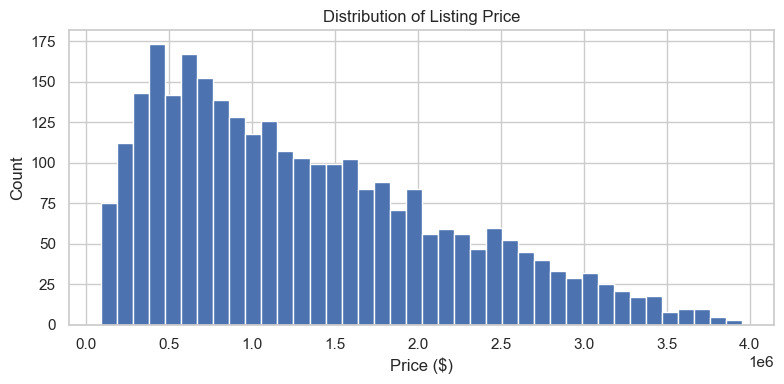

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
listings["Price"].dropna().hist(bins=40, ax=ax)
ax.set_title("Distribution of Listing Price")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Average Price by City and Property Type

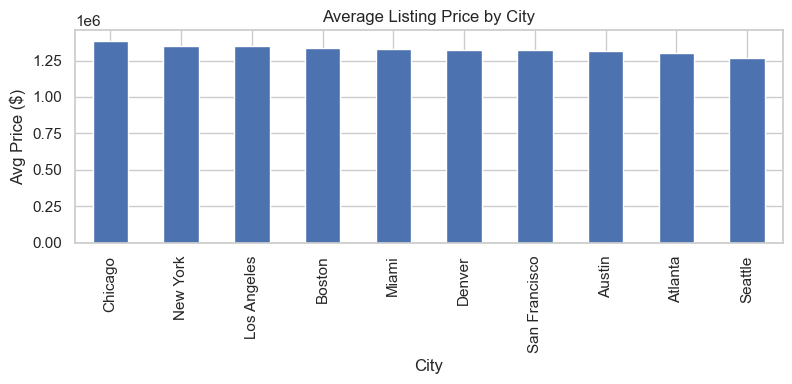

City
Chicago          1.387997e+06
New York         1.351885e+06
Los Angeles      1.349885e+06
Boston           1.339903e+06
Miami            1.331189e+06
Denver           1.321826e+06
San Francisco    1.319718e+06
Austin           1.316268e+06
Atlanta          1.301553e+06
Seattle          1.268591e+06
Name: Price, dtype: float64

In [6]:
by_city = listings.groupby("City")["Price"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
by_city.plot(kind="bar", ax=ax)
ax.set_title("Average Listing Price by City")
ax.set_ylabel("Avg Price ($)")
plt.tight_layout()
plt.show()
by_city

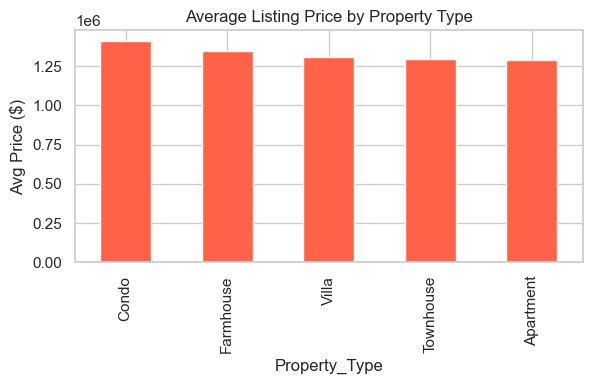

Property_Type
Condo        1.407558e+06
Farmhouse    1.347768e+06
Villa        1.306829e+06
Townhouse    1.296106e+06
Apartment    1.290232e+06
Name: Price, dtype: float64

In [7]:
by_type = listings.groupby("Property_Type")["Price"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
by_type.plot(kind="bar", ax=ax, color="tomato")
ax.set_title("Average Listing Price by Property Type")
ax.set_ylabel("Avg Price ($)")
plt.tight_layout()
plt.show()
by_type

## 4. Area vs Price

Checking whether larger properties command higher prices, and whether
the relationship differs enough by property type to be a useful
signal downstream.

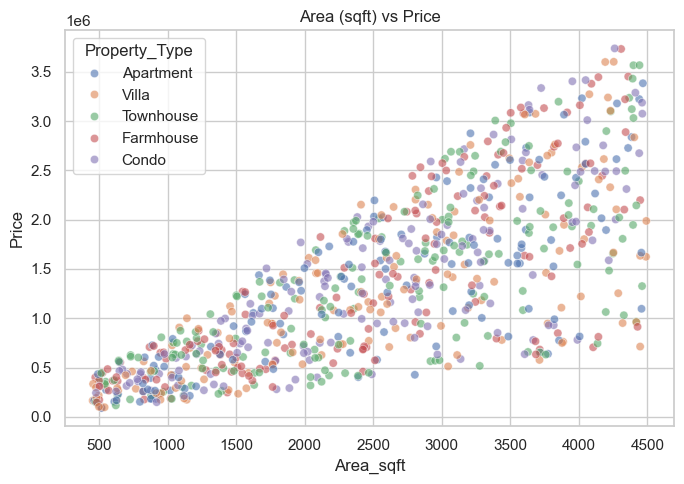

,Area_sqft,Price
Area_sqft,1.000000,0.739466
Price,0.739466,1.000000


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sample = listings.sample(min(800, len(listings)), random_state=1)
sns.scatterplot(data=sample, x="Area_sqft", y="Price", hue="Property_Type", alpha=0.6, ax=ax)
ax.set_title("Area (sqft) vs Price")
plt.tight_layout()
plt.show()

listings[["Area_sqft", "Price"]].corr()

## 5. Property Attributes — Furnishing, Metro Distance, Bedrooms

Joined against `listings` to see how the attributes captured in
`property_attributes` relate to price.

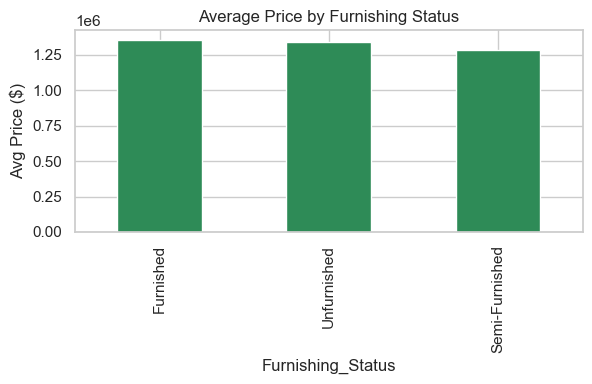

Furnishing_Status
Furnished         1.354201e+06
Unfurnished       1.341373e+06
Semi-Furnished    1.286393e+06
Name: Price, dtype: float64

In [9]:
joined = listings.merge(attrs, on="Listing_ID", how="left")

furn = joined.groupby("Furnishing_Status")["Price"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
furn.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average Price by Furnishing Status")
ax.set_ylabel("Avg Price ($)")
plt.tight_layout()
plt.show()
furn

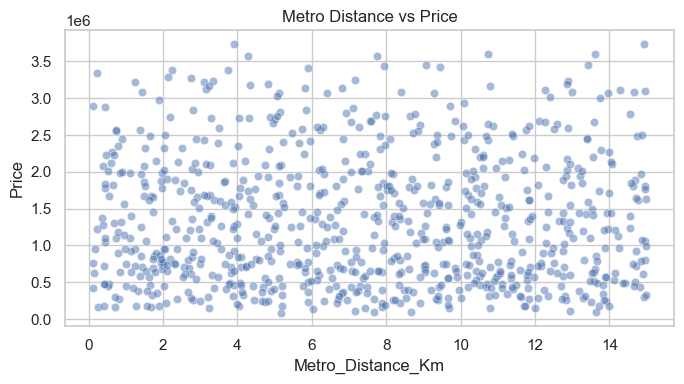

,Metro_Distance_Km,Price
Metro_Distance_Km,1.000000,0.011035
Price,0.011035,1.000000


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=joined.sample(min(800, len(joined)), random_state=1),
                 x="Metro_Distance_Km", y="Price", alpha=0.5, ax=ax)
ax.set_title("Metro Distance vs Price")
plt.tight_layout()
plt.show()

joined[["Metro_Distance_Km", "Price"]].corr()

## 6. Sales & Market Performance

`sales.Days_On_Market` and the sale-to-list price ratio are the basis
for the "Sales & Market Performance" query group (#11–#18).

In [11]:
sales["Days_On_Market"].describe()

count    1950.000000
mean       92.443077
std        50.529394
min         5.000000
25%        48.250000
50%        94.000000
75%       135.750000
max       180.000000
Name: Days_On_Market, dtype: float64

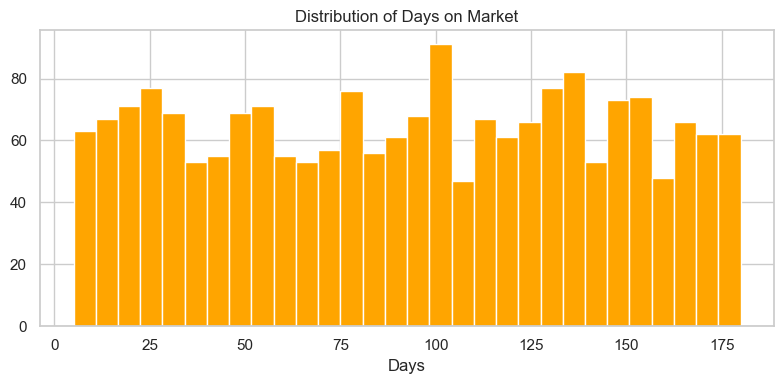

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sales["Days_On_Market"].hist(bins=30, ax=ax, color="orange")
ax.set_title("Distribution of Days on Market")
ax.set_xlabel("Days")
plt.tight_layout()
plt.show()

In [13]:
sales_joined = sales.merge(listings[["Listing_ID", "Price", "City"]], on="Listing_ID", how="left")
sales_joined["Sale_To_List_Ratio"] = sales_joined["Sale_Price"] / sales_joined["Price"]
pct_above_list = (sales_joined["Sale_Price"] > sales_joined["Price"]).mean() * 100
print(f"% sold above listing price: {pct_above_list:.1f}%")
sales_joined["Sale_To_List_Ratio"].describe()

% sold above listing price: 53.4%


count    1907.000000
mean        1.011868
std         0.063997
min         0.900069
25%         0.957522
50%         1.012902
75%         1.067952
max         1.119962
Name: Sale_To_List_Ratio, dtype: float64

## 7. Buyer & Financing Behavior

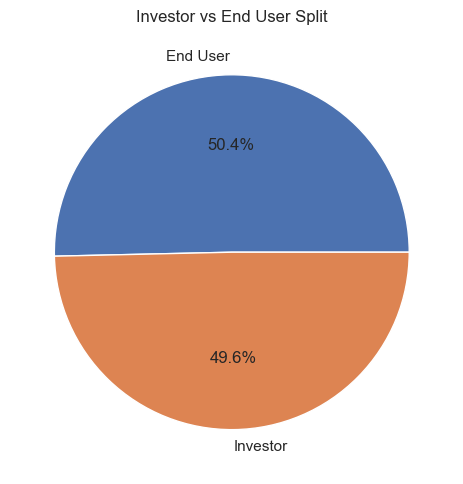

Buyer_Type
End User    50.358974
Investor    49.641026
Name: proportion, dtype: float64

In [14]:
buyer_type_split = buyers["Buyer_Type"].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(5, 5))
buyer_type_split.plot(kind="pie", autopct="%1.1f%%", ax=ax, ylabel="")
ax.set_title("Investor vs End User Split")
plt.tight_layout()
plt.show()
buyer_type_split

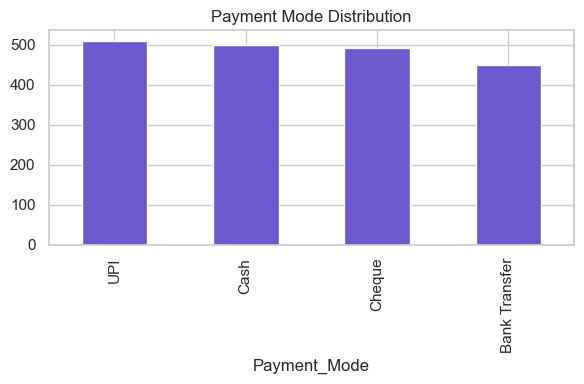

Payment_Mode
UPI              510
Cash             499
Cheque           492
Bank Transfer    449
Name: count, dtype: int64

In [15]:
payment_mode = buyers["Payment_Mode"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
payment_mode.plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Payment Mode Distribution")
plt.tight_layout()
plt.show()
payment_mode

## 8. Correlation Overview

Numeric-feature correlation across the joined listings + attributes
table, to sanity-check which variables actually move together before
trusting the SQL query outputs built on top of them.

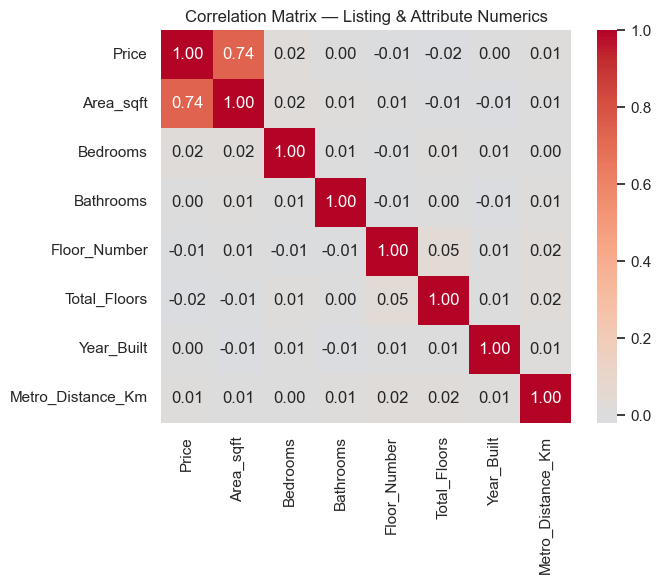

In [16]:
numeric_cols = ["Price", "Area_sqft", "Bedrooms", "Bathrooms", "Floor_Number",
                "Total_Floors", "Year_Built", "Metro_Distance_Km"]
corr = joined[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Listing & Attribute Numerics")
plt.tight_layout()
plt.show()

## Key Takeaways

- **Missing values are real, not edge cases**: `Price` is missing for
  62/3,000 listings (2%), `Is_Rented` for 47, and `Furnishing_Status`
  for a notable 800/3,000 (~27%). `build_database.py` fills these with
  city+type median, `False`, and `"Unfurnished"` respectively — worth
  knowing that a quarter of "Unfurnished" rows in the cleaned data are
  actually imputed, not observed.
- **A genuine data gap**: of the 1,950 buyers, 947 didn't take a loan
  (so a missing `Loan_Provider` is expected) — but **156 buyers who did
  take a loan still have no `Loan_Provider` recorded**. The current
  pipeline doesn't fill or flag this; it's a real gap, not noise.
- **`Area_sqft` is the strongest simple predictor of `Price`**
  (r ≈ 0.74). City and property type each shift the average price
  level by low-to-mid six figures, which is why queries #1, #2 and #9
  slice price by both.
- **Metro distance barely correlates with price here** (r ≈ 0.01) —
  contrary to intuition, and worth flagging since query #4 buckets
  listings by metro distance expecting a pricing relationship that
  this particular (synthetic) dataset doesn't actually show.
- **Furnishing status has only a modest effect on price**: Furnished
  ($1.354M avg) > Unfurnished ($1.341M) > Semi-Furnished ($1.286M) — a
  ~$68K spread, smaller than the effect of city or property type.
- **Days-on-market (5–180 days, mean ≈ 92, median ≈ 94) and
  sale-to-list ratio (tightly centered around 1.01) are both fairly
  symmetric** rather than long-tailed — 53.4% of sales close above the
  original listing price.
- **Buyer type (≈50/50 investor vs. end user) and payment mode (roughly
  even across Cash/UPI/Bank/Cheque) are both close to uniform** — useful
  as filters in the app, weak as standalone predictors of price or
  speed on their own.
